In [41]:
print("all ok")

all ok


In [42]:
from dotenv import load_dotenv
load_dotenv()
from langchain_groq import ChatGroq
llm=ChatGroq(model_name="deepseek-r1-distill-llama-70b")

In [43]:
llm.invoke("What is the capital of France?")

AIMessage(content='<think>\n\n</think>\n\nThe capital of France is Paris.', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 12, 'prompt_tokens': 10, 'total_tokens': 22, 'completion_time': 0.055209195, 'prompt_time': 0.000204087, 'queue_time': 0.20929587300000002, 'total_time': 0.055413282}, 'model_name': 'deepseek-r1-distill-llama-70b', 'system_fingerprint': 'fp_1bbe7845ec', 'finish_reason': 'stop', 'logprobs': None}, id='run--08c53d92-631d-4a10-b583-dbbca7258639-0', usage_metadata={'input_tokens': 10, 'output_tokens': 12, 'total_tokens': 22})

In [44]:
from langchain_core.tools import tool
from langchain_community.tools.tavily_search import TavilySearchResults

In [45]:
@tool
def multiply(x: int, y: int) -> int:
    """Multiplies two numbers."""
    return x * y

In [46]:
multiply({"x":2, "y":3})

6

In [47]:
@tool
def search(query: str):
    """search the web for a query and return the results"""
    tavily=TavilySearchResults()
    result=tavily.invoke(query)
    return f"Result for {query} is: \n{result}"

In [48]:
print(search.invoke({"query":"What is the capital of France?"}))

Result for What is the capital of France? is: 
[{'title': 'Paris facts: the capital of France in history', 'url': 'https://home.adelphi.edu/~ca19535/page%204.html', 'content': 'page 4\n\n===============\n\nHomeSpainSydneySan FranciscoParisLas VegasMaui\n\n Paris, France\n\nImage 1\n\nParis facts: Paris, the capital of France\n---------------------------------------------\n\nParis is the capital of France, the largest country of Europe with 550 000 km2 (65 millions inhabitants).\n\nParis has 2.234 million inhabitants end 2011. She is the core of Ile de France region (12 million people). [...] Before Paris, the capital of France was Lyon (under the Romans). Paris first became the capital of France in 508 under King Clovis. After centuries with no unique capital of France, Paris retrieved its status of capital of France under King Philippe Auguste, who reigned between 1180 and 1223. You can see remains of the Philippe August Paris walls in the passageway between the Louvre parking and Lou

In [49]:
tools = [multiply, search]

In [50]:
tools

[StructuredTool(name='multiply', description='Multiplies two numbers.', args_schema=<class 'langchain_core.utils.pydantic.multiply'>, func=<function multiply at 0x0000021D0DA4E8E0>),
 StructuredTool(name='search', description='search the web for a query and return the results', args_schema=<class 'langchain_core.utils.pydantic.search'>, func=<function search at 0x0000021D0D9C0B80>)]

In [51]:
llm_with_tools=llm.bind_tools(tools)

In [52]:
result=llm_with_tools.invoke("what is current gdp of india?")

In [53]:
result.content

''

In [54]:
result.tool_calls

[{'name': 'search',
  'args': {'query': 'current GDP of India'},
  'id': '5xrr0305c',
  'type': 'tool_call'}]

In [55]:
result.tool_calls[0]["name"]

'search'

In [56]:
result.tool_calls[0]["args"]

{'query': 'current GDP of India'}

In [57]:
tool_mapping={tool.name:tool for tool in tools}

In [58]:
tool_mapping

{'multiply': StructuredTool(name='multiply', description='Multiplies two numbers.', args_schema=<class 'langchain_core.utils.pydantic.multiply'>, func=<function multiply at 0x0000021D0DA4E8E0>),
 'search': StructuredTool(name='search', description='search the web for a query and return the results', args_schema=<class 'langchain_core.utils.pydantic.search'>, func=<function search at 0x0000021D0D9C0B80>)}

In [59]:
tool_mapping["search"]

StructuredTool(name='search', description='search the web for a query and return the results', args_schema=<class 'langchain_core.utils.pydantic.search'>, func=<function search at 0x0000021D0D9C0B80>)

In [60]:
tool_mapping["search"].invoke({"query":"What is the capital of india?"})

'Result for What is the capital of india? is: \n[{\'title\': \'What is the Capital of India? - Mappr\', \'url\': \'https://www.mappr.co/capital-cities/india/\', \'content\': \'What is the Capital of India?\\n=============================\\n\\nNew Delhi is the capital of India. A cosmopolitan city in South Asia, New Delhi is home to a diverse population that speaks many different languages and holds a wide variety of religious beliefs. The city of New Delhi is part of the larger Delhi Metro Area whose population is over 32 million, and it is well-known for its chaotic traffic and large crowds. [...] New Delhi was not always the capital of India. Prior to 1911, Calcutta was the capital city of the country. India was under British rule at this time, and it was decided to move the capital away from Calcutta due to the intense anti-colonial sentiments that existed there.\\n\\nImage 4: A bustling street with various vehicles, roadside billboards, and urban development on both sides.\\n\\nTra

In [61]:
tool_mapping[result.tool_calls[0]["name"]].invoke(result.tool_calls[0]["args"])

'Result for current GDP of India is: \n[{\'title\': "Is India the world\'s fourth largest economy? - The Hindu", \'url\': \'https://www.thehindu.com/business/Economy/is-india-the-worlds-fourth-largest-economy/article69645115.ece\', \'content\': \'India has a large GDP size, but it is also host to the world’s largest population. One can boast about its GDP size only until someone sits down and divides the GDP by the population. The per capita GDP in India was $2,711 in 2024 in current dollar terms, which placed it at the lower end of the list of “lower middle-income countries”. In the same year, the per capita GDP in Sri Lanka was $4,325, and in Bhutan was $3,913. In 1991, India had a higher per capita GDP at $304 than in Vietnam at [...] Over the past week, much media space was devoted to discussions around the size of India’s economy relative to other economies of the world. These discussions were based on the new estimates of the Gross Domestic Product (GDP) of various countries for 

In [62]:
from typing import TypedDict, Sequence, Annotated
import operator
from langchain_core.messages import BaseMessage

In [63]:
class AgentState(TypedDict):
    """State for the agent."""
    messages: Annotated[Sequence[BaseMessage],operator.add]

In [64]:
# state={"messages":["hi","hello","how are you?"]}

In [65]:
def invoke_model(state:AgentState):
    messages=state["messages"]
    question=messages[-1]
    response=llm_with_tools.invoke(question)
    return {"messages":[response]}
    
    

In [66]:
def router(state:AgentState):
    tool_calls=state["messages"][-1].tool_calls
    if len(tool_calls)>0:
        return "tool" #key name
    else:
        return "end" #key name

In [67]:
def invoke_tool(state:AgentState):
    tool_details=state["messages"][-1].tool_calls
    
    if tool_details is None:
        return Exception("No tool calls found in the last message.")
    
    print(f"Seleted tool: {tool_details[0]['name']}")
    
    if tool_details[0]["name"]=="search":
        response=input(prompt=f"[yes/no] do you want to continue with this expensive web search")
        if response.lower()=="no":
            print("web search discarded by the user. exiting gracefully")
            raise Exception("Web search discarded by the user.")
            
    
    response=tool_mapping[tool_details[0]["name"]].invoke(tool_details[0]["args"])
    return {"messages":[response]}
            

In [68]:
tools

[StructuredTool(name='multiply', description='Multiplies two numbers.', args_schema=<class 'langchain_core.utils.pydantic.multiply'>, func=<function multiply at 0x0000021D0DA4E8E0>),
 StructuredTool(name='search', description='search the web for a query and return the results', args_schema=<class 'langchain_core.utils.pydantic.search'>, func=<function search at 0x0000021D0D9C0B80>)]

In [69]:
from langgraph.graph import StateGraph, START,END
graph=StateGraph(AgentState)
graph.add_node("ai_assistant", invoke_model)
graph.add_node("tool", invoke_tool)


In [70]:
graph.add_conditional_edges("ai_assistant",
                            router,
                            {
                                "tool":"tool", ##with the key tool which value is associated <tool>
                                "end":END
                            }
                            )

In [71]:
graph.add_edge("tool", END)

In [72]:
graph.set_entry_point("ai_assistant")

In [73]:
app=graph.compile()

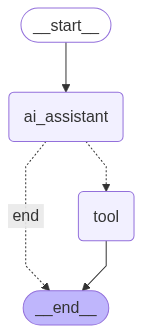

In [74]:
from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))

In [75]:
app.invoke({"messages":["What is the current gdp of the india?"]})

Seleted tool: search


{'messages': ['What is the current gdp of the india?',
  AIMessage(content='', additional_kwargs={'tool_calls': [{'id': '7q6c4e3br', 'function': {'arguments': '{"query":"current GDP of India"}', 'name': 'search'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 103, 'prompt_tokens': 176, 'total_tokens': 279, 'completion_time': 0.374545455, 'prompt_time': 0.01093707, 'queue_time': 0.205528715, 'total_time': 0.385482525}, 'model_name': 'deepseek-r1-distill-llama-70b', 'system_fingerprint': 'fp_1bbe7845ec', 'finish_reason': 'tool_calls', 'logprobs': None}, id='run--557b5e7c-aa81-480b-b41e-1418c341069e-0', tool_calls=[{'name': 'search', 'args': {'query': 'current GDP of India'}, 'id': '7q6c4e3br', 'type': 'tool_call'}], usage_metadata={'input_tokens': 176, 'output_tokens': 103, 'total_tokens': 279}),
  'Result for current GDP of India is: \n[{\'title\': \'India GDP 2025 - StatisticsTimes.com\', \'url\': \'https://statisticstimes.com/economy/country/india-gdp.

In [76]:
app.invoke({"messages":["What is the multiplication of 5 and 20?"]})

Seleted tool: multiply


{'messages': ['What is the multiplication of 5 and 20?',
  AIMessage(content='', additional_kwargs={'tool_calls': [{'id': '1cd312wmm', 'function': {'arguments': '{"x":5,"y":20}', 'name': 'multiply'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 256, 'prompt_tokens': 177, 'total_tokens': 433, 'completion_time': 1.066149124, 'prompt_time': 0.011053419, 'queue_time': 0.214075773, 'total_time': 1.077202543}, 'model_name': 'deepseek-r1-distill-llama-70b', 'system_fingerprint': 'fp_1bbe7845ec', 'finish_reason': 'tool_calls', 'logprobs': None}, id='run--66c93e7c-9165-4869-bf3d-e48bed40f7c9-0', tool_calls=[{'name': 'multiply', 'args': {'x': 5, 'y': 20}, 'id': '1cd312wmm', 'type': 'tool_call'}], usage_metadata={'input_tokens': 177, 'output_tokens': 256, 'total_tokens': 433}),
  100]}

In [77]:
app.invoke({"messages":["What is the current weather in india delhi?"]})

Seleted tool: search
web search discarded by the user. exiting gracefully


Exception: Web search discarded by the user.

In [78]:
app.invoke({"messages":["what is a latest news of bengaluru?"]})

Seleted tool: search


{'messages': ['what is a latest news of bengaluru?',
  AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'cnz79cv6j', 'function': {'arguments': '{"query":"latest news Bengaluru"}', 'name': 'search'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 182, 'prompt_tokens': 177, 'total_tokens': 359, 'completion_time': 0.872189462, 'prompt_time': 0.011048768, 'queue_time': 0.20837933600000003, 'total_time': 0.88323823}, 'model_name': 'deepseek-r1-distill-llama-70b', 'system_fingerprint': 'fp_1bbe7845ec', 'finish_reason': 'tool_calls', 'logprobs': None}, id='run--dcb44388-a160-4ae4-8330-24a14acb2a1f-0', tool_calls=[{'name': 'search', 'args': {'query': 'latest news Bengaluru'}, 'id': 'cnz79cv6j', 'type': 'tool_call'}], usage_metadata={'input_tokens': 177, 'output_tokens': 182, 'total_tokens': 359}),
  'Result for latest news Bengaluru is: \n[{\'title\': \'Bengaluru - The New Indian Express\', \'url\': \'https://www.newindianexpress.com/cities/bengalu

Langgraph Based Workflow

In [80]:
tools

[StructuredTool(name='multiply', description='Multiplies two numbers.', args_schema=<class 'langchain_core.utils.pydantic.multiply'>, func=<function multiply at 0x0000021D0DA4E8E0>),
 StructuredTool(name='search', description='search the web for a query and return the results', args_schema=<class 'langchain_core.utils.pydantic.search'>, func=<function search at 0x0000021D0D9C0B80>)]

In [85]:
from langgraph.prebuilt import ToolNode, tools_condition
tool_node=ToolNode(tools)

In [81]:
class AgentState(TypedDict):
    messages: Annotated[Sequence[BaseMessage], operator.add]

In [82]:
llm_with_tools=llm.bind_tools(tools)

In [83]:
def ai_assistant(state:AgentState):
    response=llm_with_tools.invoke(state["messages"])
    return {"messages":[response]}

In [84]:
from langgraph.checkpoint.memory import MemorySaver
memory=MemorySaver()
graph_builder=StateGraph(AgentState)


In [86]:
graph_builder=StateGraph(AgentState)
graph_builder.add_node("ai_assistant", ai_assistant)
graph_builder.add_node("tools", tool_node)
graph_builder.add_edge(START,"ai_assistant")


In [87]:
graph_builder.add_conditional_edges("ai_assistant",
                                    tools_condition,
                                    )

In [88]:
graph_builder.add_edge("tools", "ai_assistant")

In [89]:
app2=graph_builder.compile(checkpointer=memory,interrupt_before=["tools"])

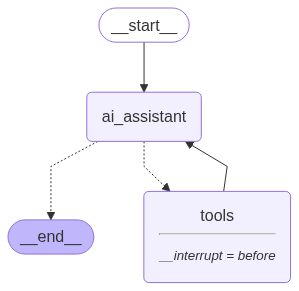

In [90]:
from IPython.display import Image, display
display(Image(app2.get_graph().draw_mermaid_png()))

In [91]:
config={"configurable":{"thread_id":"1"}}

In [92]:
from langchain_core.messages import HumanMessage
response=app2.invoke({"messages":[HumanMessage("What is the current gdp of the china?")]},config=config)

In [93]:
response

{'messages': [HumanMessage(content='What is the current gdp of the china?', additional_kwargs={}, response_metadata={}),
  AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'pxy2geq3r', 'function': {'arguments': '{"query":"current GDP of China"}', 'name': 'search'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 139, 'prompt_tokens': 176, 'total_tokens': 315, 'completion_time': 0.588328577, 'prompt_time': 0.017821896, 'queue_time': 0.204194454, 'total_time': 0.606150473}, 'model_name': 'deepseek-r1-distill-llama-70b', 'system_fingerprint': 'fp_1bbe7845ec', 'finish_reason': 'tool_calls', 'logprobs': None}, id='run--f772aa27-2ad5-44d1-b8c6-2d034ce906ba-0', tool_calls=[{'name': 'search', 'args': {'query': 'current GDP of China'}, 'id': 'pxy2geq3r', 'type': 'tool_call'}], usage_metadata={'input_tokens': 176, 'output_tokens': 139, 'total_tokens': 315})]}

In [94]:
snapshot=app2.get_state(config)

In [95]:
snapshot

StateSnapshot(values={'messages': [HumanMessage(content='What is the current gdp of the china?', additional_kwargs={}, response_metadata={}), AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'pxy2geq3r', 'function': {'arguments': '{"query":"current GDP of China"}', 'name': 'search'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 139, 'prompt_tokens': 176, 'total_tokens': 315, 'completion_time': 0.588328577, 'prompt_time': 0.017821896, 'queue_time': 0.204194454, 'total_time': 0.606150473}, 'model_name': 'deepseek-r1-distill-llama-70b', 'system_fingerprint': 'fp_1bbe7845ec', 'finish_reason': 'tool_calls', 'logprobs': None}, id='run--f772aa27-2ad5-44d1-b8c6-2d034ce906ba-0', tool_calls=[{'name': 'search', 'args': {'query': 'current GDP of China'}, 'id': 'pxy2geq3r', 'type': 'tool_call'}], usage_metadata={'input_tokens': 176, 'output_tokens': 139, 'total_tokens': 315})]}, next=('tools',), config={'configurable': {'thread_id': '1', 'checkpoint_n

In [ ]:
StateSnapshot(values={'messages': [HumanMessage(content='What is the current gdp of the china?', additional_kwargs={}, response_metadata={}), AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'pxy2geq3r', 'function': {'arguments': '{"query":"current GDP of China"}', 'name': 'search'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 139, 'prompt_tokens': 176, 'total_tokens': 315, 'completion_time': 0.588328577, 'prompt_time': 0.017821896, 'queue_time': 0.204194454, 'total_time': 0.606150473}, 'model_name': 'deepseek-r1-distill-llama-70b', 'system_fingerprint': 'fp_1bbe7845ec', 'finish_reason': 'tool_calls', 'logprobs': None}, id='run--f772aa27-2ad5-44d1-b8c6-2d034ce906ba-0', tool_calls=[{'name': 'search', 'args': {'query': 'current GDP of China'}, 'id': 'pxy2geq3r', 'type': 'tool_call'}], usage_metadata={'input_tokens': 176, 'output_tokens': 139, 'total_tokens': 315})]}, next=('tools',), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f05b050-cbbc-6599-8001-93b29c16fe0a'}}, metadata={'source': 'loop', 'writes': {'ai_assistant': {'messages': [AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'pxy2geq3r', 'function': {'arguments': '{"query":"current GDP of China"}', 'name': 'search'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 139, 'prompt_tokens': 176, 'total_tokens': 315, 'completion_time': 0.588328577, 'prompt_time': 0.017821896, 'queue_time': 0.204194454, 'total_time': 0.606150473}, 'model_name': 'deepseek-r1-distill-llama-70b', 'system_fingerprint': 'fp_1bbe7845ec', 'finish_reason': 'tool_calls', 'logprobs': None}, id='run--f772aa27-2ad5-44d1-b8c6-2d034ce906ba-0', tool_calls=[{'name': 'search', 'args': {'query': 'current GDP of China'}, 'id': 'pxy2geq3r', 'type': 'tool_call'}], usage_metadata={'input_tokens': 176, 'output_tokens': 139, 'total_tokens': 315})]}}, 'step': 1, 'parents': {}, 'thread_id': '1'}, created_at='2025-07-07T07:36:09.508174+00:00', parent_config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f05b050-c0f8-66c1-8000-ffff434dc979'}}, tasks=(PregelTask(id='280ad242-3b84-ab92-5411-e47a64635bdc', name='tools', path=('__pregel_pull', 'tools'), error=None, interrupts=(), state=None, result=None),), interrupts=())


In [96]:
snapshot.next

('tools',)

In [97]:
last_message=snapshot.values["messages"][-1]

In [98]:
last_message

AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'pxy2geq3r', 'function': {'arguments': '{"query":"current GDP of China"}', 'name': 'search'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 139, 'prompt_tokens': 176, 'total_tokens': 315, 'completion_time': 0.588328577, 'prompt_time': 0.017821896, 'queue_time': 0.204194454, 'total_time': 0.606150473}, 'model_name': 'deepseek-r1-distill-llama-70b', 'system_fingerprint': 'fp_1bbe7845ec', 'finish_reason': 'tool_calls', 'logprobs': None}, id='run--f772aa27-2ad5-44d1-b8c6-2d034ce906ba-0', tool_calls=[{'name': 'search', 'args': {'query': 'current GDP of China'}, 'id': 'pxy2geq3r', 'type': 'tool_call'}], usage_metadata={'input_tokens': 176, 'output_tokens': 139, 'total_tokens': 315})

In [99]:
last_message.tool_calls

[{'name': 'search',
  'args': {'query': 'current GDP of China'},
  'id': 'pxy2geq3r',
  'type': 'tool_call'}]

In [104]:
app2.invoke(None, config)

{'messages': [HumanMessage(content='What is the current gdp of the china?', additional_kwargs={}, response_metadata={}),
  AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'pxy2geq3r', 'function': {'arguments': '{"query":"current GDP of China"}', 'name': 'search'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 139, 'prompt_tokens': 176, 'total_tokens': 315, 'completion_time': 0.588328577, 'prompt_time': 0.017821896, 'queue_time': 0.204194454, 'total_time': 0.606150473}, 'model_name': 'deepseek-r1-distill-llama-70b', 'system_fingerprint': 'fp_1bbe7845ec', 'finish_reason': 'tool_calls', 'logprobs': None}, id='run--f772aa27-2ad5-44d1-b8c6-2d034ce906ba-0', tool_calls=[{'name': 'search', 'args': {'query': 'current GDP of China'}, 'id': 'pxy2geq3r', 'type': 'tool_call'}], usage_metadata={'input_tokens': 176, 'output_tokens': 139, 'total_tokens': 315}),
  ToolMessage(content='Result for current GDP of China is: \n[{\'title\': \'China GDP - Tradin

In [101]:
tool_details=last_message.tool_calls

In [102]:
tool_details[0]["name"]

'search'

In [103]:
if tool_details[0]["name"]== "search":
    user_input=input(prompt=f"[yes/no] do you want to continue with {tool_details[0]['name']}?").lower()
    if user_input=="no":
        print("web tool discarded")
        raise Exception("Web tool discarded by the user.")
    else:
        response=app2.invoke(None,config)
        print(response)
else:
    response=app2.invoke(None,config)
    print(response)

{'messages': [HumanMessage(content='What is the current gdp of the china?', additional_kwargs={}, response_metadata={}), AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'pxy2geq3r', 'function': {'arguments': '{"query":"current GDP of China"}', 'name': 'search'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 139, 'prompt_tokens': 176, 'total_tokens': 315, 'completion_time': 0.588328577, 'prompt_time': 0.017821896, 'queue_time': 0.204194454, 'total_time': 0.606150473}, 'model_name': 'deepseek-r1-distill-llama-70b', 'system_fingerprint': 'fp_1bbe7845ec', 'finish_reason': 'tool_calls', 'logprobs': None}, id='run--f772aa27-2ad5-44d1-b8c6-2d034ce906ba-0', tool_calls=[{'name': 'search', 'args': {'query': 'current GDP of China'}, 'id': 'pxy2geq3r', 'type': 'tool_call'}], usage_metadata={'input_tokens': 176, 'output_tokens': 139, 'total_tokens': 315}), ToolMessage(content='Result for current GDP of China is: \n[{\'title\': \'China GDP - Trading Ec

In [ ]:
{'messages': [HumanMessage(content='What is the current gdp of the china?', additional_kwargs={}, response_metadata={}), AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'pxy2geq3r', 'function': {'arguments': '{"query":"current GDP of China"}', 'name': 'search'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 139, 'prompt_tokens': 176, 'total_tokens': 315, 'completion_time': 0.588328577, 'prompt_time': 0.017821896, 'queue_time': 0.204194454, 'total_time': 0.606150473}, 'model_name': 'deepseek-r1-distill-llama-70b', 'system_fingerprint': 'fp_1bbe7845ec', 'finish_reason': 'tool_calls', 'logprobs': None}, id='run--f772aa27-2ad5-44d1-b8c6-2d034ce906ba-0', tool_calls=[{'name': 'search', 'args': {'query': 'current GDP of China'}, 'id': 'pxy2geq3r', 'type': 'tool_call'}], usage_metadata={'input_tokens': 176, 'output_tokens': 139, 'total_tokens': 315}), ToolMessage(content='Result for current GDP of China is: \n[{\'title\': \'China GDP - Trading Economics\', \'url\': \'https://tradingeconomics.com/china/gdp\', \'content\': \'##### Members\\n\\n##### \\n\\n# China GDP\\n\\n## The Gross Domestic Product (GDP) in China was worth 18743.80 billion US dollars in 2024, according to official data from the World Bank. The GDP value of China represents 17.65 percent of the world economy. source: World Bank [...] ## GDP in China averaged 3590.13 USD Billion from 1960 until 2024, reaching an all time high of 18743.80 USD Billion in 2024 and a record low of 47.31 USD Billion in 1962. This page provides - China GDP - actual values, historical data, forecast, chart, statistics, economic calendar and news. China GDP - values, historical data and charts - was last updated on July of 2025. [...] ### GDP in China is expected to reach 19531.00 USD Billion by the end of 2025, according to Trading Economics global macro models and analysts expectations. In the long-term, the China GDP is projected to trend around 20312.00 USD Billion in 2026 and 21165.00 USD Billion in 2027, according to our econometric models.\', \'score\': 0.8524574}, {\'title\': \'China: GDP at current prices 1985-2030 - Statista\', \'url\': \'https://www.statista.com/statistics/263770/gross-domestic-product-gdp-of-china/\', \'content\': "China\'s real GDP growth was 3.1 percent in 2022 and 5.4 percent in 2023. In 2024, per capita GDP in China reached around 13,300 U.S. dollars.", \'score\': 0.8338803}, {\'title\': \'National Bureau of Statistics of China - National Data\', \'url\': \'https://data.stats.gov.cn/english/easyquery.htm?cn=B01\', \'content\': \'4Q 2023 ; Gross Domestic Product, Current Quarter(100 million yuan), 318758.0, 373726.2, 341758.0, 328837.6 ; Gross Domestic Product, Accumulated(100 million yuan)\', \'score\': 0.81770587}, {\'title\': \'China GDP Annual Growth Rate - Trading Economics\', \'url\': \'https://tradingeconomics.com/china/gdp-growth-annual\', \'content\': \'## The Gross Domestic Product (GDP) in China expanded 5.40 percent in the first quarter of 2025 over the same quarter of the previous year. GDP Annual Growth Rate in China averaged 8.78 percent from 1989 until 2025, reaching an all time high of 18.90 percent in the first quarter of 2021 and a record low of -6.80 percent in the first quarter of 2020. This page provides - China GDP Annual Growth Rate - actual values, historical data, forecast, chart, statistics, economic calendar and news. China [...] | Related | Last | Unit | Reference |\\n| --- | --- | --- | --- |\\n| Full Year GDP Growth | 5.00 | percent | Dec 2024 |\\n| GDP Growth Rate YoY | 5.40 | percent | Mar 2025 |\\n| GDP Constant Prices | 306612.20 | CNY Hundred Million | Mar 2025 |\\n| GDP from Agriculture | 11712.80 | CNY Hundred Million | Mar 2025 |\\n| GDP from Construction | 14429.90 | CNY Hundred Million | Mar 2025 |\\n| GDP from Manufacturing | 98344.50 | CNY Hundred Million | Mar 2025 | [...] | GDP from Services | 195142.30 | CNY Hundred Million | Mar 2025 |\\n| GDP from Transport | 13892.50 | CNY Hundred Million | Mar 2025 |\\n| GDP Growth Rate | 1.20 | percent | Mar 2025 |\\n| Gross Fixed Capital Formation | 537875.60 | CNY Hundred Million | Dec 2024 |\\n| Gross National Income | 1339672.00 | CNY Hundred Million | Dec 2024 |\', \'score\': 0.78214747}, {\'title\': \'China GDP Growth Rate | Historical Chart & Data - Macrotrends\', \'url\': \'https://www.macrotrends.net/global-metrics/countries/chn/china/gdp-growth-rate\', \'content\': \'China gdp growth rate for 2023 was 5.25%, a 2.3% increase from 2022. China gdp growth rate for 2022 was 2.95%, a 5.5% decline from 2021. China gdp growth\', \'score\': 0.7016523}]', name='search', tool_call_id='pxy2geq3r'), AIMessage(content="The current GDP of China, as of 2024, is approximately **$18,743.80 billion USD**, according to data from Trading Economics. This figure represents China's contribution to the global economy, accounting for about 17.65% of the world's total GDP.", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 245, 'prompt_tokens': 1272, 'total_tokens': 1517, 'completion_time': 1.038513217, 'prompt_time': 0.102696907, 'queue_time': 0.205378878, 'total_time': 1.141210124}, 'model_name': 'deepseek-r1-distill-llama-70b', 'system_fingerprint': 'fp_1bbe7845ec', 'finish_reason': 'stop', 'logprobs': None}, id='run--fc6d5a6b-57df-4499-a83a-a5d331118911-0', usage_metadata={'input_tokens': 1272, 'output_tokens': 245, 'total_tokens': 1517})]}


In [105]:
from langchain_core.messages import AIMessage,ToolMessage

In [108]:
response=app2.invoke({"messages":[HumanMessage("What is the current gdp of the japan?")]},config=config)

In [109]:
response

{'messages': [HumanMessage(content='What is the current gdp of the china?', additional_kwargs={}, response_metadata={}),
  AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'pxy2geq3r', 'function': {'arguments': '{"query":"current GDP of China"}', 'name': 'search'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 139, 'prompt_tokens': 176, 'total_tokens': 315, 'completion_time': 0.588328577, 'prompt_time': 0.017821896, 'queue_time': 0.204194454, 'total_time': 0.606150473}, 'model_name': 'deepseek-r1-distill-llama-70b', 'system_fingerprint': 'fp_1bbe7845ec', 'finish_reason': 'tool_calls', 'logprobs': None}, id='run--f772aa27-2ad5-44d1-b8c6-2d034ce906ba-0', tool_calls=[{'name': 'search', 'args': {'query': 'current GDP of China'}, 'id': 'pxy2geq3r', 'type': 'tool_call'}], usage_metadata={'input_tokens': 176, 'output_tokens': 139, 'total_tokens': 315}),
  ToolMessage(content='Result for current GDP of China is: \n[{\'title\': \'China GDP - Tradin

In [110]:
snapshot=app2.get_state(config)

In [111]:
snapshot.next

('tools',)

In [112]:
last_message=snapshot.values["messages"][-1]

In [113]:
last_message.tool_calls

[{'name': 'search',
  'args': {'query': 'current GDP of Japan'},
  'id': '59rqnjg8q',
  'type': 'tool_call'}]

In [114]:
tool_call_id=last_message.tool_calls[0]["id"]

In [115]:
tool_call_id

'59rqnjg8q'

In [116]:
from langchain_core.messages import AIMessage,ToolMessage

In [117]:
new_message=[
    ToolMessage(content="according to the latest data 4.1 trillion USD",tool_call_id=tool_call_id),
    AIMessage(content="GDP is 4.1 Trillion USD.")
    
]

In [118]:
app2.update_state(config, 
                  {
                      "messages":new_message
                   }
                  )

{'configurable': {'thread_id': '1',
  'checkpoint_ns': '',
  'checkpoint_id': '1f05bab6-2156-60a1-8007-27ad94cf5a78'}}

In [119]:
app2.get_state(config).values["messages"][-1]

AIMessage(content='GDP is 4.1 Trillion USD.', additional_kwargs={}, response_metadata={})

In [120]:
app2.invoke(None,config=config)

{'messages': [HumanMessage(content='What is the current gdp of the china?', additional_kwargs={}, response_metadata={}),
  AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'pxy2geq3r', 'function': {'arguments': '{"query":"current GDP of China"}', 'name': 'search'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 139, 'prompt_tokens': 176, 'total_tokens': 315, 'completion_time': 0.588328577, 'prompt_time': 0.017821896, 'queue_time': 0.204194454, 'total_time': 0.606150473}, 'model_name': 'deepseek-r1-distill-llama-70b', 'system_fingerprint': 'fp_1bbe7845ec', 'finish_reason': 'tool_calls', 'logprobs': None}, id='run--f772aa27-2ad5-44d1-b8c6-2d034ce906ba-0', tool_calls=[{'name': 'search', 'args': {'query': 'current GDP of China'}, 'id': 'pxy2geq3r', 'type': 'tool_call'}], usage_metadata={'input_tokens': 176, 'output_tokens': 139, 'total_tokens': 315}),
  ToolMessage(content='Result for current GDP of China is: \n[{\'title\': \'China GDP - Tradin

In [121]:
app2.invoke({"messages":[HumanMessage("What is the current gdp of the japan?")]},config=config)

{'messages': [HumanMessage(content='What is the current gdp of the china?', additional_kwargs={}, response_metadata={}),
  AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'pxy2geq3r', 'function': {'arguments': '{"query":"current GDP of China"}', 'name': 'search'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 139, 'prompt_tokens': 176, 'total_tokens': 315, 'completion_time': 0.588328577, 'prompt_time': 0.017821896, 'queue_time': 0.204194454, 'total_time': 0.606150473}, 'model_name': 'deepseek-r1-distill-llama-70b', 'system_fingerprint': 'fp_1bbe7845ec', 'finish_reason': 'tool_calls', 'logprobs': None}, id='run--f772aa27-2ad5-44d1-b8c6-2d034ce906ba-0', tool_calls=[{'name': 'search', 'args': {'query': 'current GDP of China'}, 'id': 'pxy2geq3r', 'type': 'tool_call'}], usage_metadata={'input_tokens': 176, 'output_tokens': 139, 'total_tokens': 315}),
  ToolMessage(content='Result for current GDP of China is: \n[{\'title\': \'China GDP - Tradin